### Goal



Test the perfomance of the following time series models as the baseline model for short-term prediction:
- [Holt-Winters (Triple Exponential Smoothing)](https://www.statsmodels.org/devel/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html)
- [ARIMA](https://www.statsmodels.org/devel/generated/statsmodels.tsa.arima.model.ARIMA.html#statsmodels.tsa.arima.model.ARIMA)

We will first use the category `hep-ph` ("High Energy Physics - Phenomenology") as a testing case, and then do the model comparison for all the categories.

### Data processing


In [2]:
import pandas, numpy, matplotlib, seaborn, sklearn, statsmodels, prophet
print("All packages imported successfully!")

All packages imported successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from seaborn import set_style
from sklearn.metrics import mean_squared_error

set_style("whitegrid")

We load the data from `data/arxiv-totals.parquet` and set up our training data set from 01/01/2001 (Monday) to 03/14/2025 (Monday), and testing data set to 03/17/2025 (Monday).

In [4]:
df = pd.read_parquet("../data/arxiv-totals.parquet")

df_train = df[
    (df.index >= pd.Timestamp(2001, 1, 1)) & (df.index <= pd.Timestamp(2025, 3, 14))
]
df_test = df[df.index >= pd.Timestamp(2025, 3, 17)]

In [5]:
print(df.columns)
print(df_train.shape, df_test.shape)
print(df.head())

Index(['hep-th', 'physics.pop-ph', 'math.LO', 'math.FA', 'math.MG', 'cs.CC',
       'math.CO', 'math.PR', 'math.DS', 'cs.GR',
       ...
       'econ.EM', 'stat.CO', 'stat.OT', 'q-fin.EC', 'eess.SY', 'econ.GN',
       'eess.AS', 'eess.IV', 'eess.SP', 'q-fin.MF'],
      dtype='object', length=158)
(6315, 158) (20, 158)
            hep-th  physics.pop-ph  math.LO  math.FA  math.MG  cs.CC  math.CO  \
date                                                                            
1986-04-28     1.0             1.0      0.0      0.0      0.0    0.0      0.0   
1988-11-14     1.0             0.0      0.0      0.0      0.0    0.0      0.0   
1989-04-17     0.0             0.0      1.0      0.0      0.0    0.0      0.0   
1989-10-27     0.0             0.0      0.0      3.0      3.0    0.0      0.0   
1989-11-10     0.0             0.0      0.0      1.0      1.0    0.0      0.0   

            math.PR  math.DS  cs.GR  ...  econ.EM  stat.CO  stat.OT  q-fin.EC  \
date                           

To get a sense of how these look like, we plot the submissions from the `hep` (High Energy Physics) category.

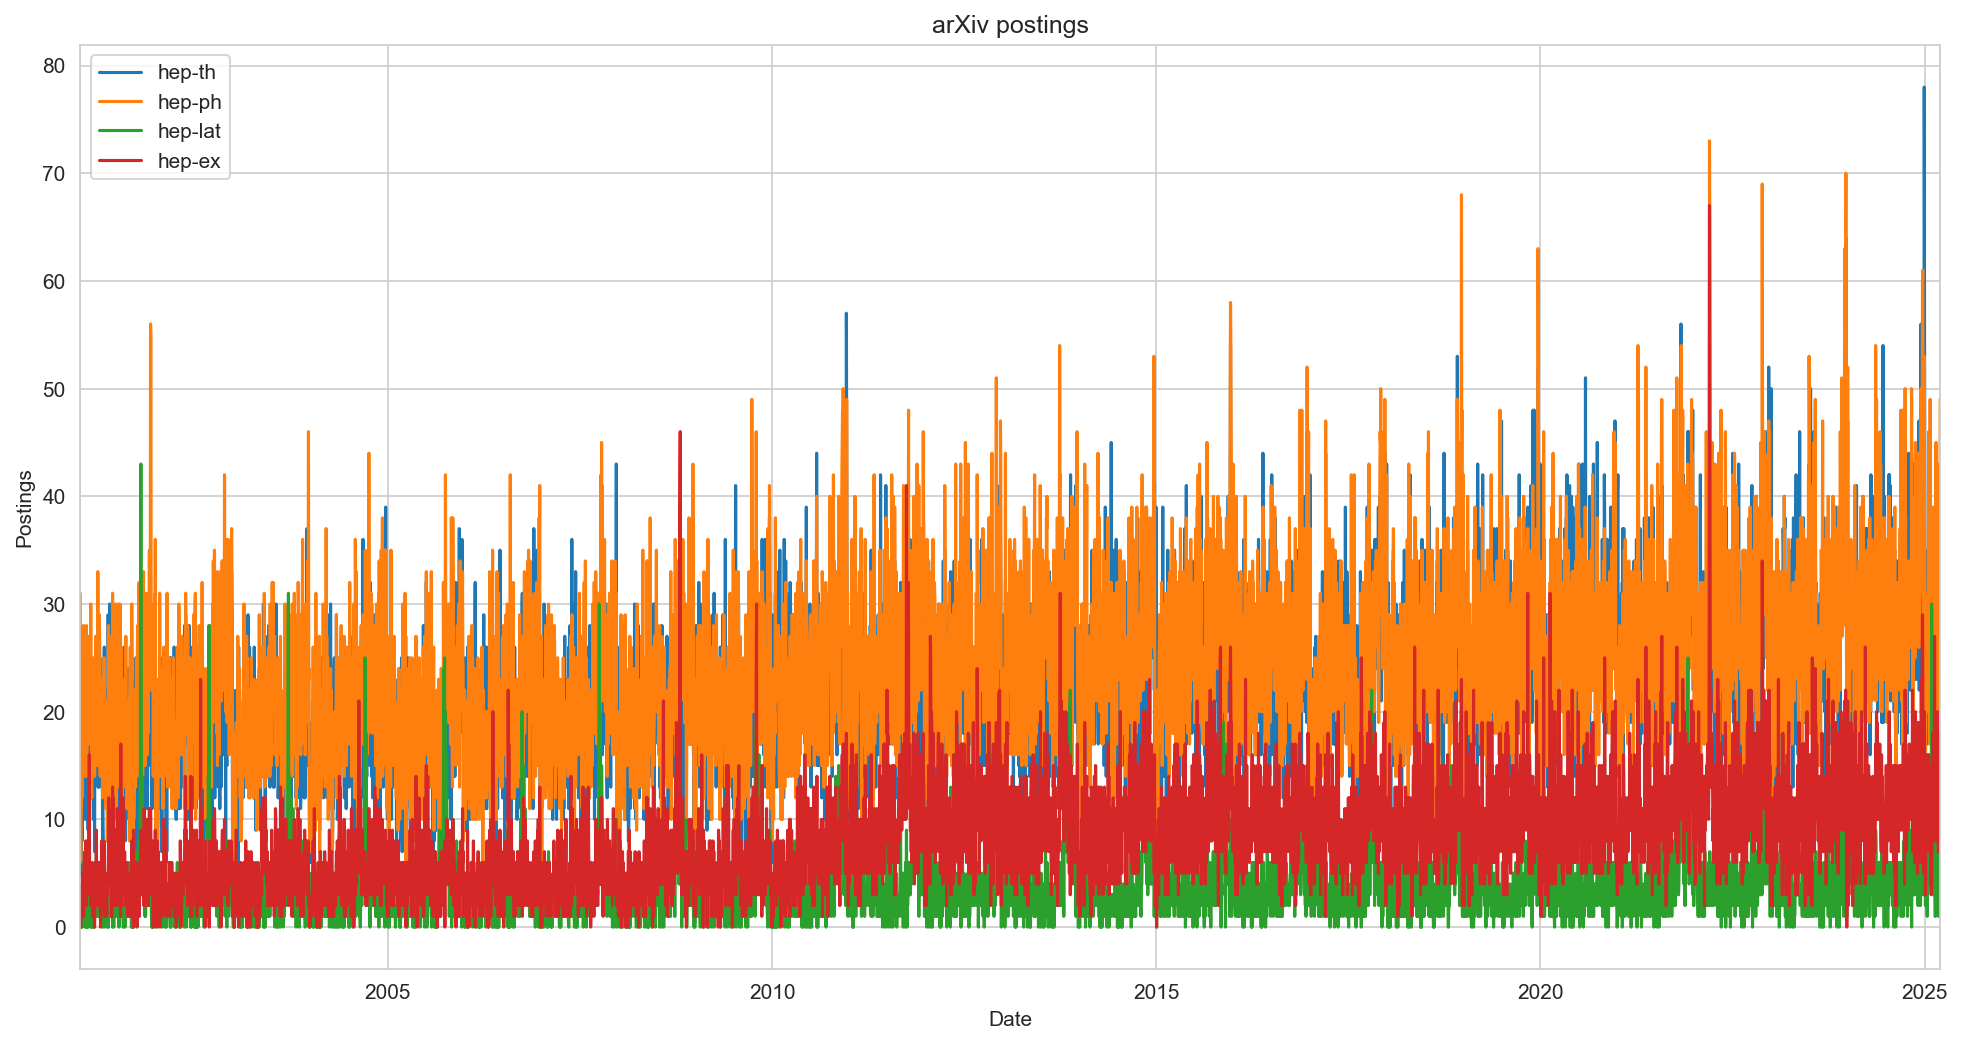

In [6]:
import matplotlib.pyplot as plt

# set plot size
plt.figure(figsize=(16, 8), dpi=150)

# adding the plots
for label, content in df_train.items():
    if label.startswith("hep-"):  # type: ignore
        content.plot(label=label)

# adding title to the plot
plt.title("arXiv postings")

# adding labels
plt.xlabel("Date")
plt.ylabel("Postings")

# adding legend to the curve
plt.legend()

We also plot `hep-ph` ("High Energy Physics - Phenomenology") by itself.

Text(0, 0.5, 'Postings')

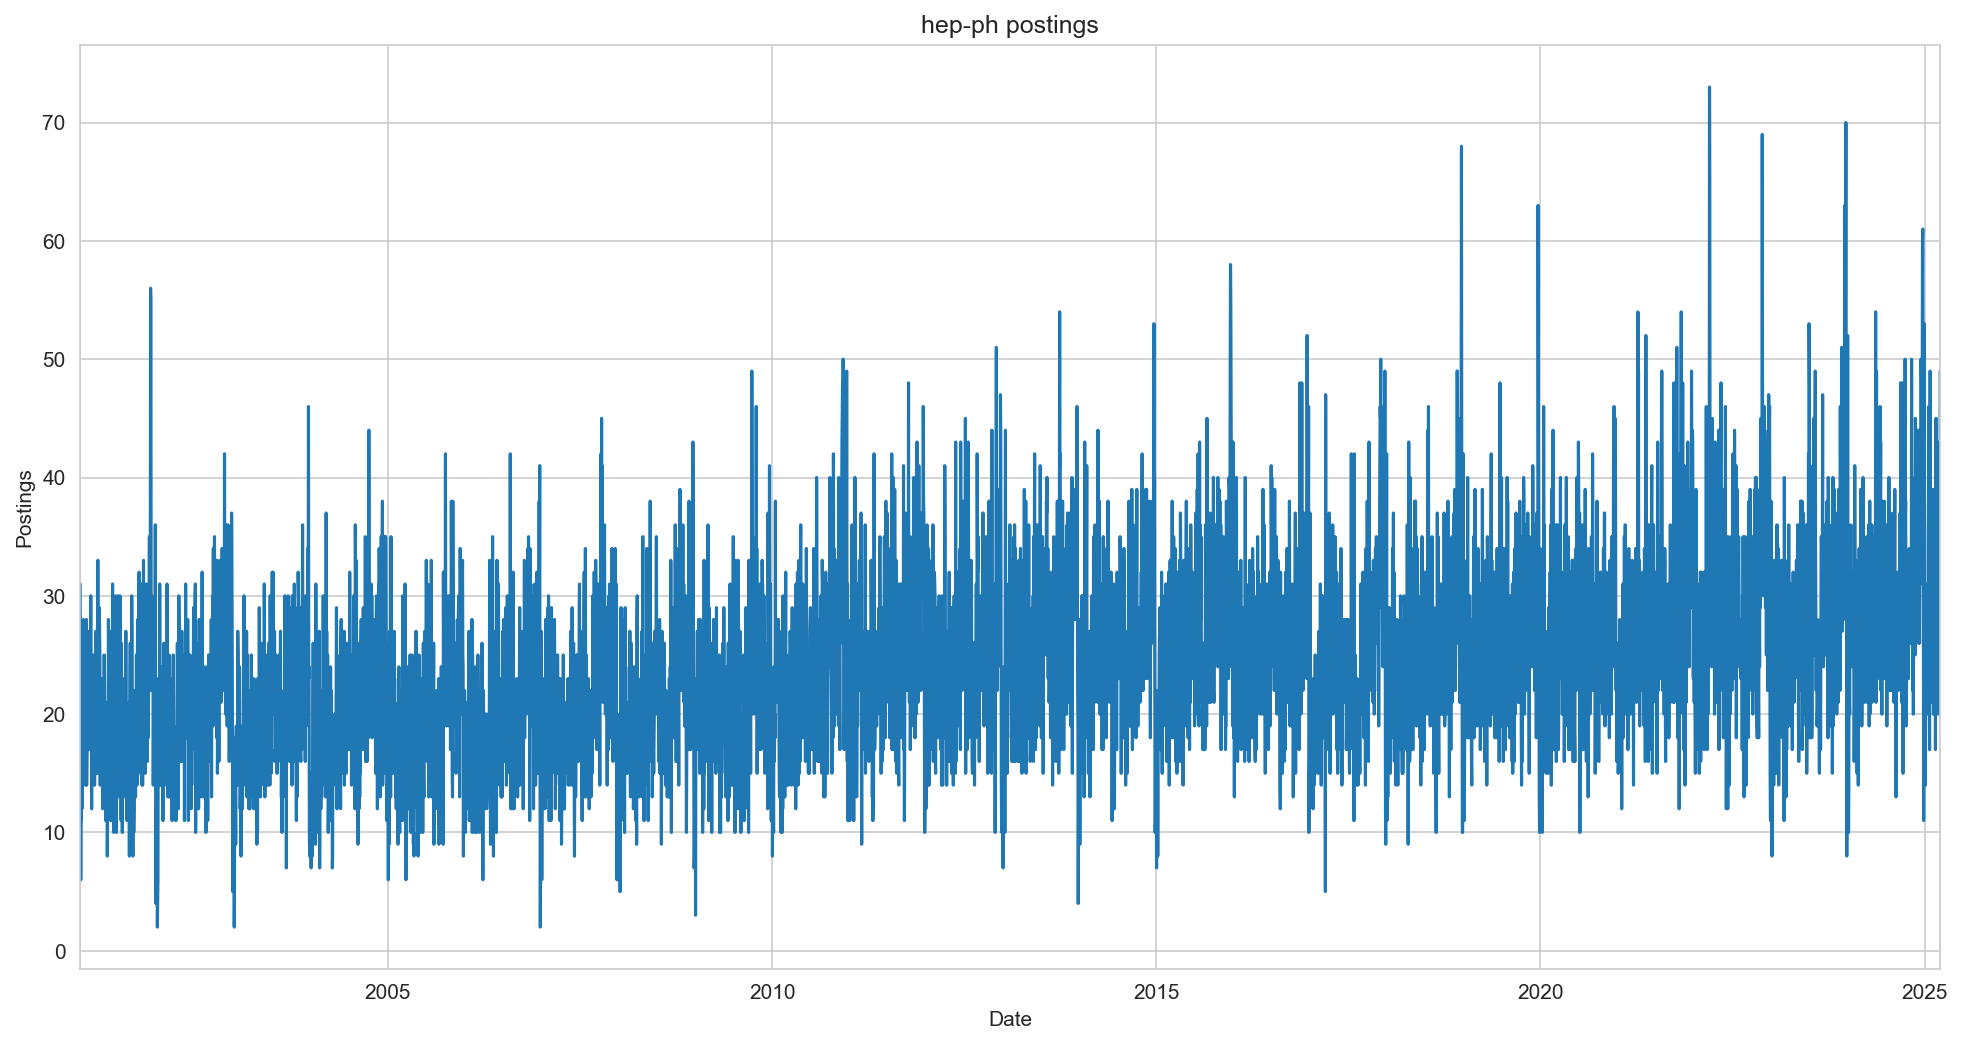

In [7]:
plt.figure(figsize=(16, 8), dpi=150)

df_train["hep-ph"].plot()

plt.title("hep-ph postings")
plt.xlabel("Date")
plt.ylabel("Postings")

We plot autocorrelation and partial autocorrelation for this last time series.

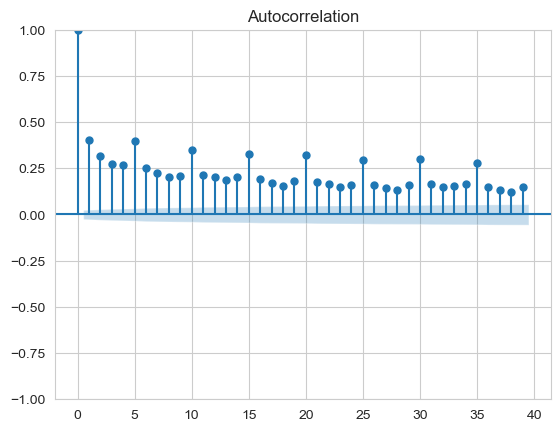

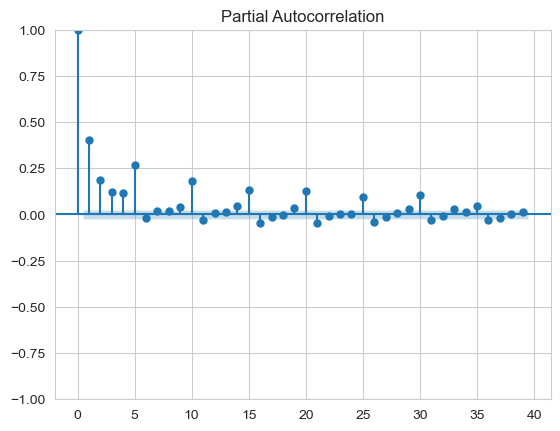

In [8]:
import statsmodels.api as sm

# Set the index to be a business day frequency
df_train = df_train.asfreq("B")

_ = sm.graphics.tsa.plot_acf(df_train["hep-ph"])
_ = sm.graphics.tsa.plot_pacf(df_train["hep-ph"])

# from statsmodels.tsa.statespace.sarimax import SARIMAX
# model = SARIMAX(
#     df_train["hep-ph"],
#     order=(1, 0, 0),
#     seasonal_order=(1, 0, 0, 12),
#     enforce_stationarity=False,
#     enforce_invertibility=False,
# )
# results = model.fit(disp=False)
# print(results.summary())
# pred = results.get_prediction(
#     start=pd.Timestamp(2025, 3, 17), dynamic=False
# )


This indicates that the time series has seasonality, with season of a week. Other categories exhibit similar correlograms, so effective models should likely take weekly seasonality into account (notice that the seasonal parameter should be 5 instead of 7 since the papers are only submitted on business days). Looking at the graphs, there is also a global trend to take into account.

### Set-up

We will use [statsmodels](https://www.statsmodels.org/stable/index.html) as our choice of time series library (Install the module `statsmodels` by using Anaconda `conda install -c conda-forge statsmodels`). In partucular, see [Time Series analysis `tsa`](https://www.statsmodels.org/devel/tsa.html).

In [9]:
## Importing statsmodels to check that we have it installed
import statsmodels as sm

In [10]:
## printing the statsmodels version
print(sm.__version__)

0.14.4


### Holt-Winters: category `hep-ph`

In [18]:
from statsmodels.tsa.api import ExponentialSmoothing

#### Additive version

In [19]:
## Call ExponentialSmoothing
## input the training data
## set seasonal = "mul", for additive you would set it equal to "add"
## You set m using seasonal_periods = 
## Then call fit
## set a smoothing_level, alpha
## set a smoothing_trend, beta
## set a smoothing_seasonal, gamma
## Set optimized = False, unless you want maximum likelihood to estimate alpha, beta, gamma
holt_winter = ExponentialSmoothing(
    df_train["hep-ph"],  # Use a single time series column
    trend='add',         # Additive trend
    # seasonal='add',      # Additive seasonality
    seasonal_periods=52
).fit(
    smoothing_level=0.1,
    smoothing_trend=0.1,
    smoothing_seasonal=0.8,
    optimized=False
)

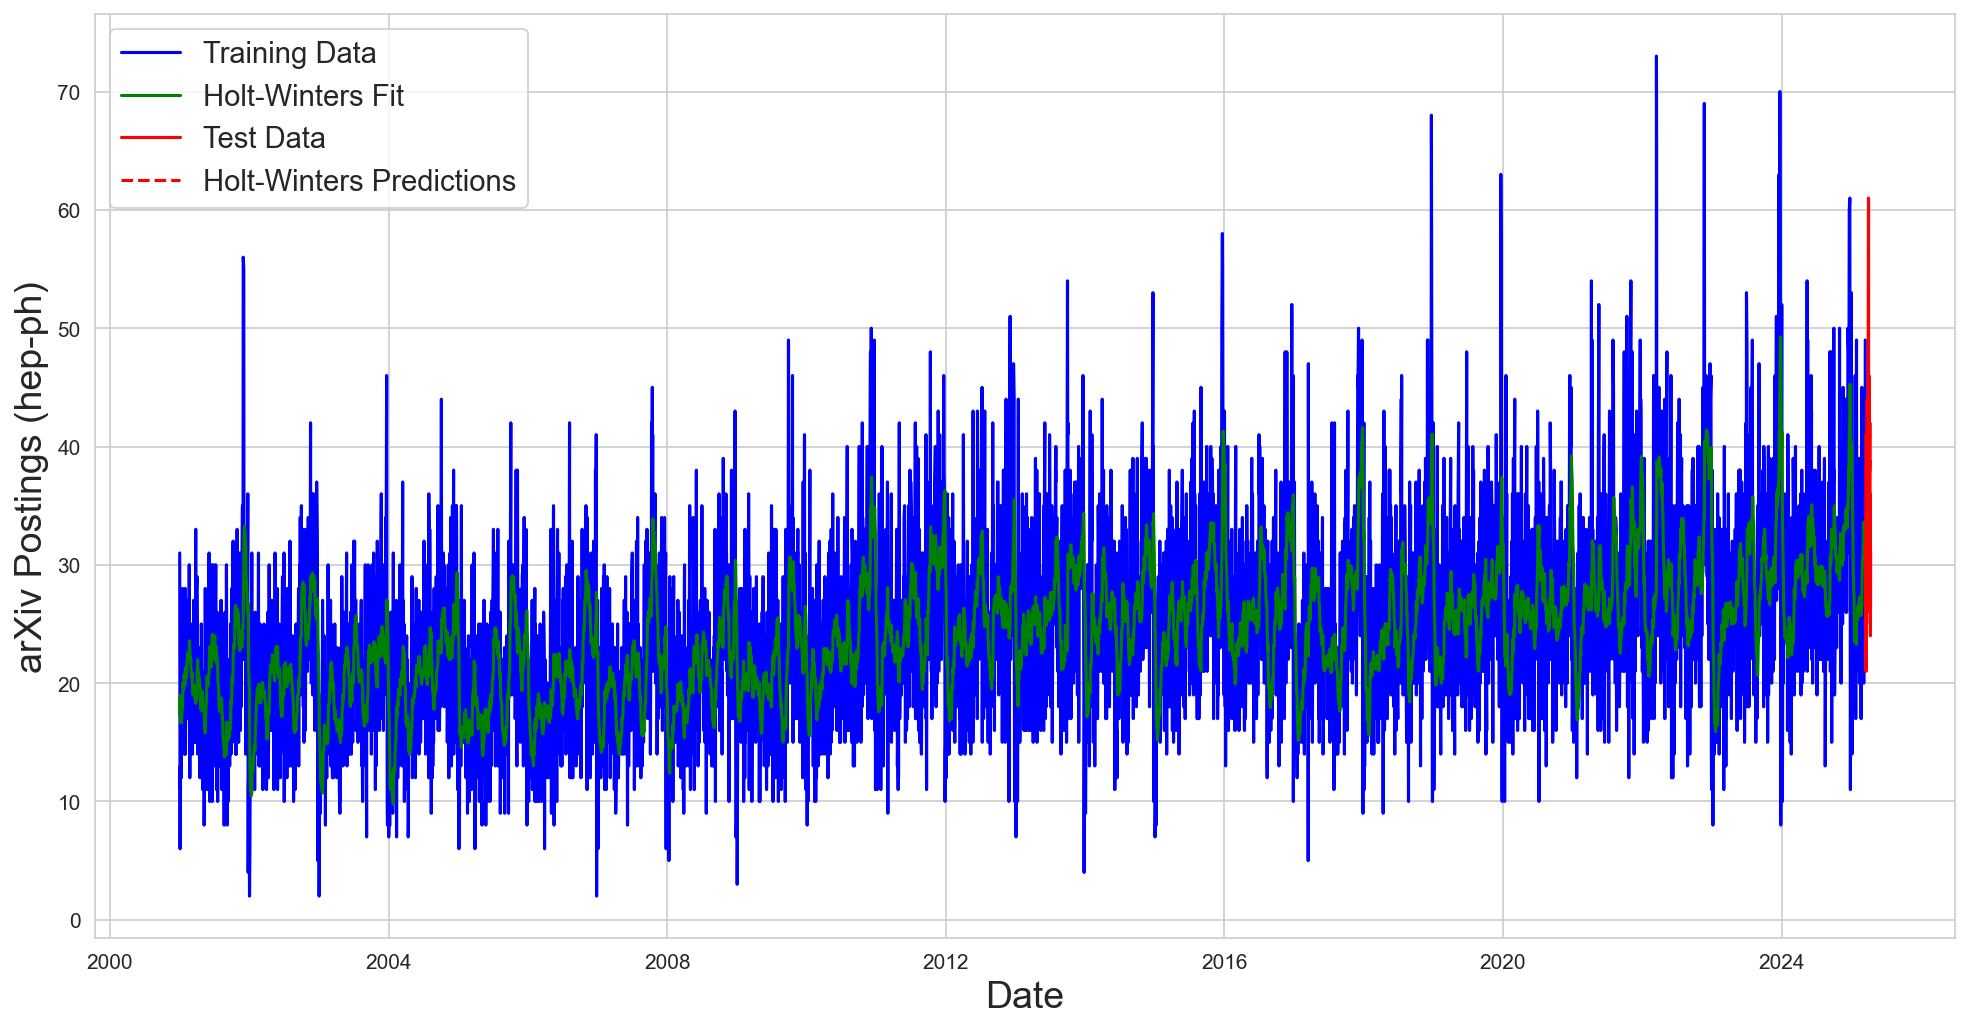

In [20]:
plt.figure(figsize=(16, 8), dpi=150)

plt.plot(df_train.index, 
         df_train["hep-ph"],
         'b-',
         label="Training Data")
plt.plot(df_train.index, 
         holt_winter.fittedvalues, 
         'g-',
         label="Holt-Winters Fit")

plt.plot(df_test.index, 
         df_test["hep-ph"],
         'r-',
         label="Test Data")

plt.plot(df_test.index, 
         holt_winter.forecast(len(df_test)),
         'r--',
         label="Holt-Winters Predictions")

plt.xlabel("Date", fontsize=18)
plt.ylabel("arXiv Postings (hep-ph)", fontsize=18)
plt.legend(fontsize=14)
plt.show()

#### Multiplicative version

In [21]:
## Call ExponentialSmoothing
## input the training data
## set seasonal = "mul", for additive you would set it equal to "add"
## You set m using seasonal_periods = 
## Then call fit
## set a smoothing_level, alpha
## set a smoothing_trend, beta
## set a smoothing_seasonal, gamma
## Set optimized = False, unless you want maximum likelihood to estimate alpha, beta, gamma
holt_winter = ExponentialSmoothing(
    df_train["hep-ph"],  # Use a single time series column
    seasonal='mul',
    seasonal_periods=52
).fit(
    smoothing_level=0.1,
    smoothing_trend=0.1,
    smoothing_seasonal=0.8,
    optimized=False
)

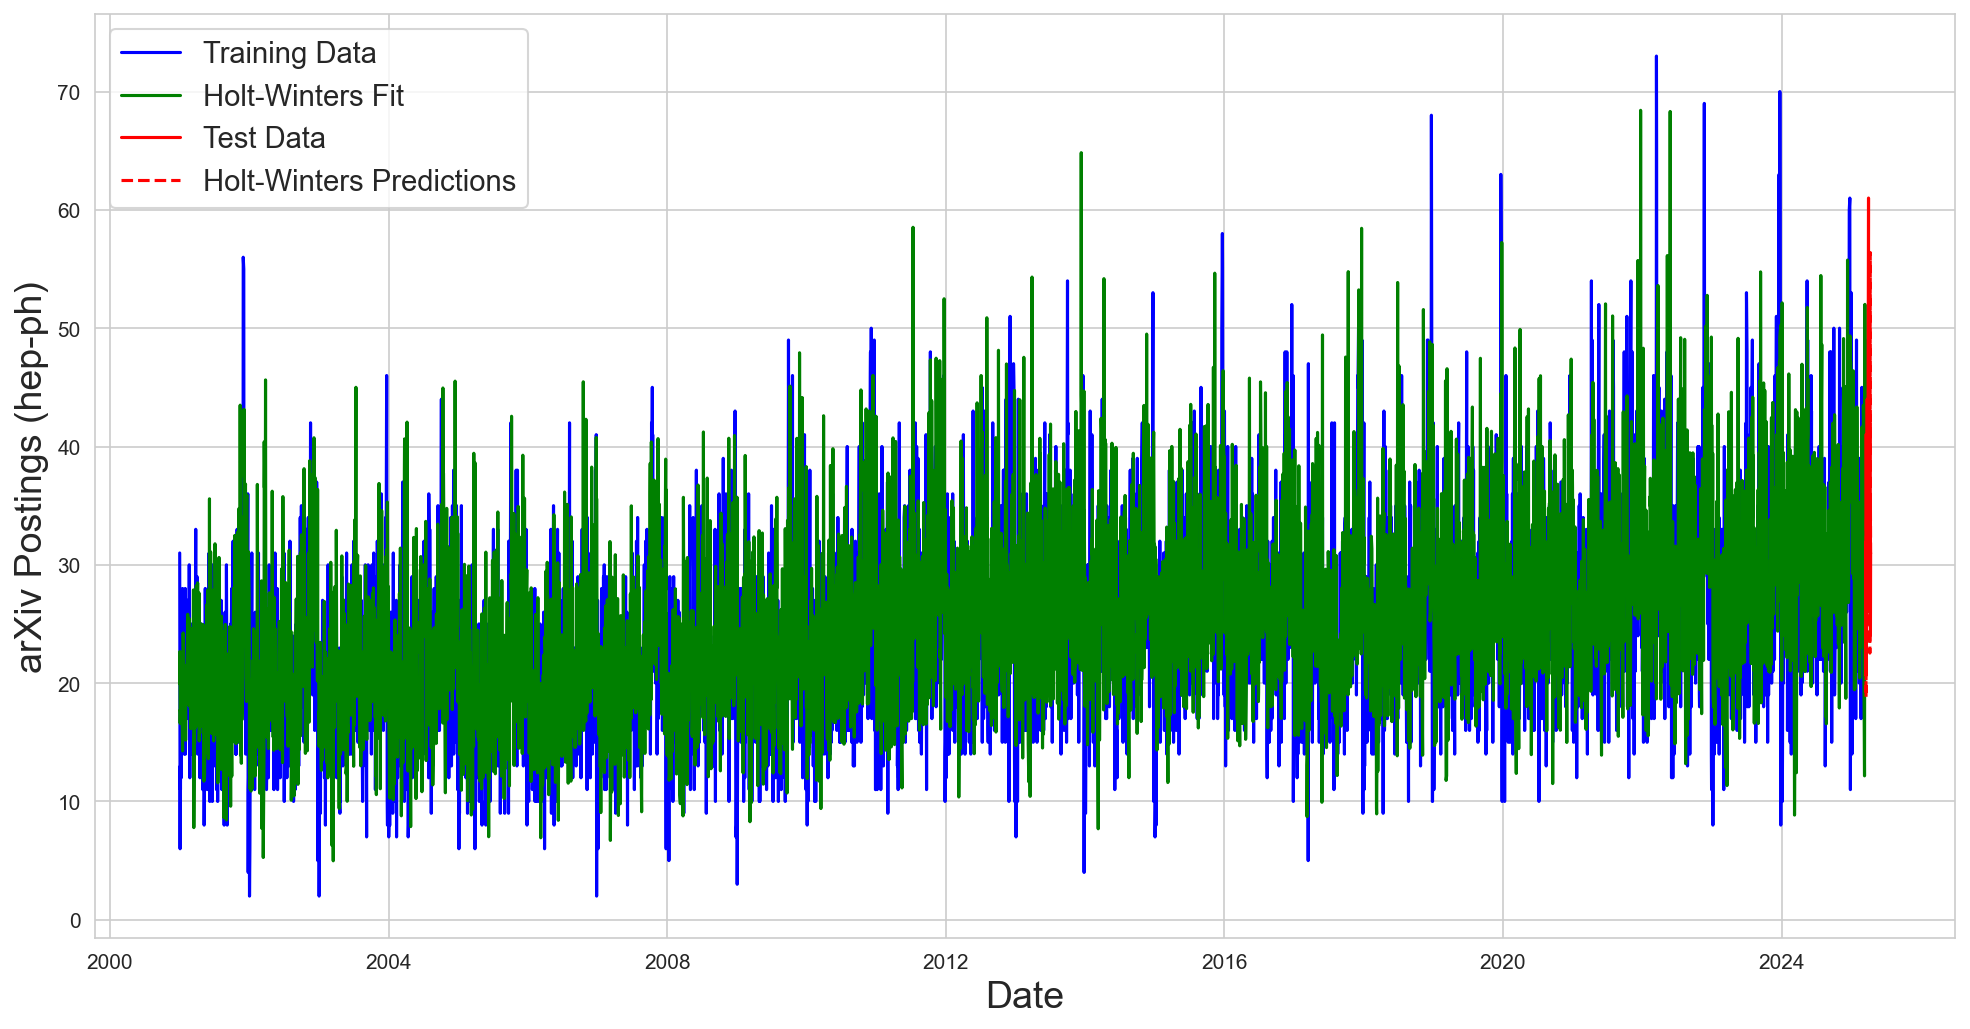

In [22]:
plt.figure(figsize=(16, 8), dpi=150)

plt.plot(df_train.index, 
         df_train["hep-ph"],
         'b-',
         label="Training Data")
plt.plot(df_train.index, 
         holt_winter.fittedvalues, 
         'g-',
         label="Holt-Winters Fit")

plt.plot(df_test.index, 
         df_test["hep-ph"],
         'r-',
         label="Test Data")

plt.plot(df_test.index, 
         holt_winter.forecast(len(df_test)),
         'r--',
         label="Holt-Winters Predictions")

plt.xlabel("Date", fontsize=18)
plt.ylabel("arXiv Postings (hep-ph)", fontsize=18)
plt.legend(fontsize=14)
plt.show()

#### Grid search & cross-validation

Use a validation or cross-validation (CV) to find the best combination of the hyperparameters `trend`, `damped_trend`, `seasonal`.  

##### EST Non-CV


First we can do a grid search with one split (best-split) minimizing MSE.

In [23]:
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np

best_score = float('inf')
best_params = None

trend_options = [None, 'add']
seasonal_options = ['add', 'mul']
damped_options = [True, False]
seasonal_periods_options = [5, 12, 52]  # adjust as needed

for trend in trend_options:
    for seasonal in seasonal_options:
        for damped in damped_options:
            for seasonal_periods in seasonal_periods_options:
                try:
                    model = ExponentialSmoothing(
                        df_train["hep-ph"],
                        trend=trend,
                        seasonal=seasonal,
                        seasonal_periods=seasonal_periods,
                        damped_trend=damped
                    ).fit(optimized=True)
                    preds = model.forecast(len(df_test))
                    score = mean_squared_error(df_test["hep-ph"], preds)
                    if score < best_score:
                        best_score = score
                        best_params = (trend, seasonal, damped, seasonal_periods)
                except Exception as e:
                    continue

print("Best params:", best_params)
print("Best MSE:", best_score)

KeyboardInterrupt: 

##### EST CV

We can also do a grid search with cross-validation minimizing the average CV MSE. 


We set up our cross-validation as:
- `n_splits`=5
- `test_size`=15
- `max_train_size`=150

We now prepare a 5-fold validation. We take a gap of 5 business days between train and validation splits, and we take a test size of 15 business days (our forecasting horizon is 5 business days).

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

trend_options = [None, 'add']
seasonal_options = ['add', 'mul']
damped_options = [True, False]
seasonal_periods_options = [5, 12, 52]  # weekly, monthly, yearly

best_score = float('inf')
best_params = None

# Setup the cross-validation
# Define the number of splits and test size
ts_cv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)
# Generate splits
splits = [(train_idx, test_idx) for train_idx, test_idx in ts_cv.split(df_train)]

# Run the grid search with CV
for trend in trend_options:
    for seasonal in seasonal_options:
        for damped in damped_options:
            for seasonal_periods in seasonal_periods_options:
                try:
                    cv_scores = []
                    for train_index, test_index in ts_cv.split(df_train):
                        y_train = df_train["hep-ph"].iloc[train_index]
                        y_test = df_train["hep-ph"].iloc[test_index]

                        model = ExponentialSmoothing(
                            y_train,
                            trend=trend,
                            seasonal=seasonal,
                            seasonal_periods=seasonal_periods,
                            damped_trend=damped
                        ).fit(optimized=True)

                        preds = model.forecast(len(y_test))
                        score = mean_squared_error(y_test, preds)
                        cv_scores.append(score)

                    avg_score = np.mean(cv_scores)
                    if avg_score < best_score:
                        best_score = avg_score
                        best_params = (trend, seasonal, damped, seasonal_periods)
                except Exception:
                    continue

print("Best params:", best_params)
print("Best average CV MSE:", round(best_score, 4))


Best params: (None, 'add', False, 5)
Best average CV MSE: 127.148


### ARIMA (SARIMA): category `hep-ph`

#### Manual ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Fit ARIMA model on math.NT
arima_model = ARIMA(df_train["hep-ph"], order=(1, 1, 1), seasonal_order=(1, 0, 0, 52))
arima_results = arima_model.fit()

# Forecast for the length of the test set
arima_preds = arima_results.forecast(steps=len(df_test))

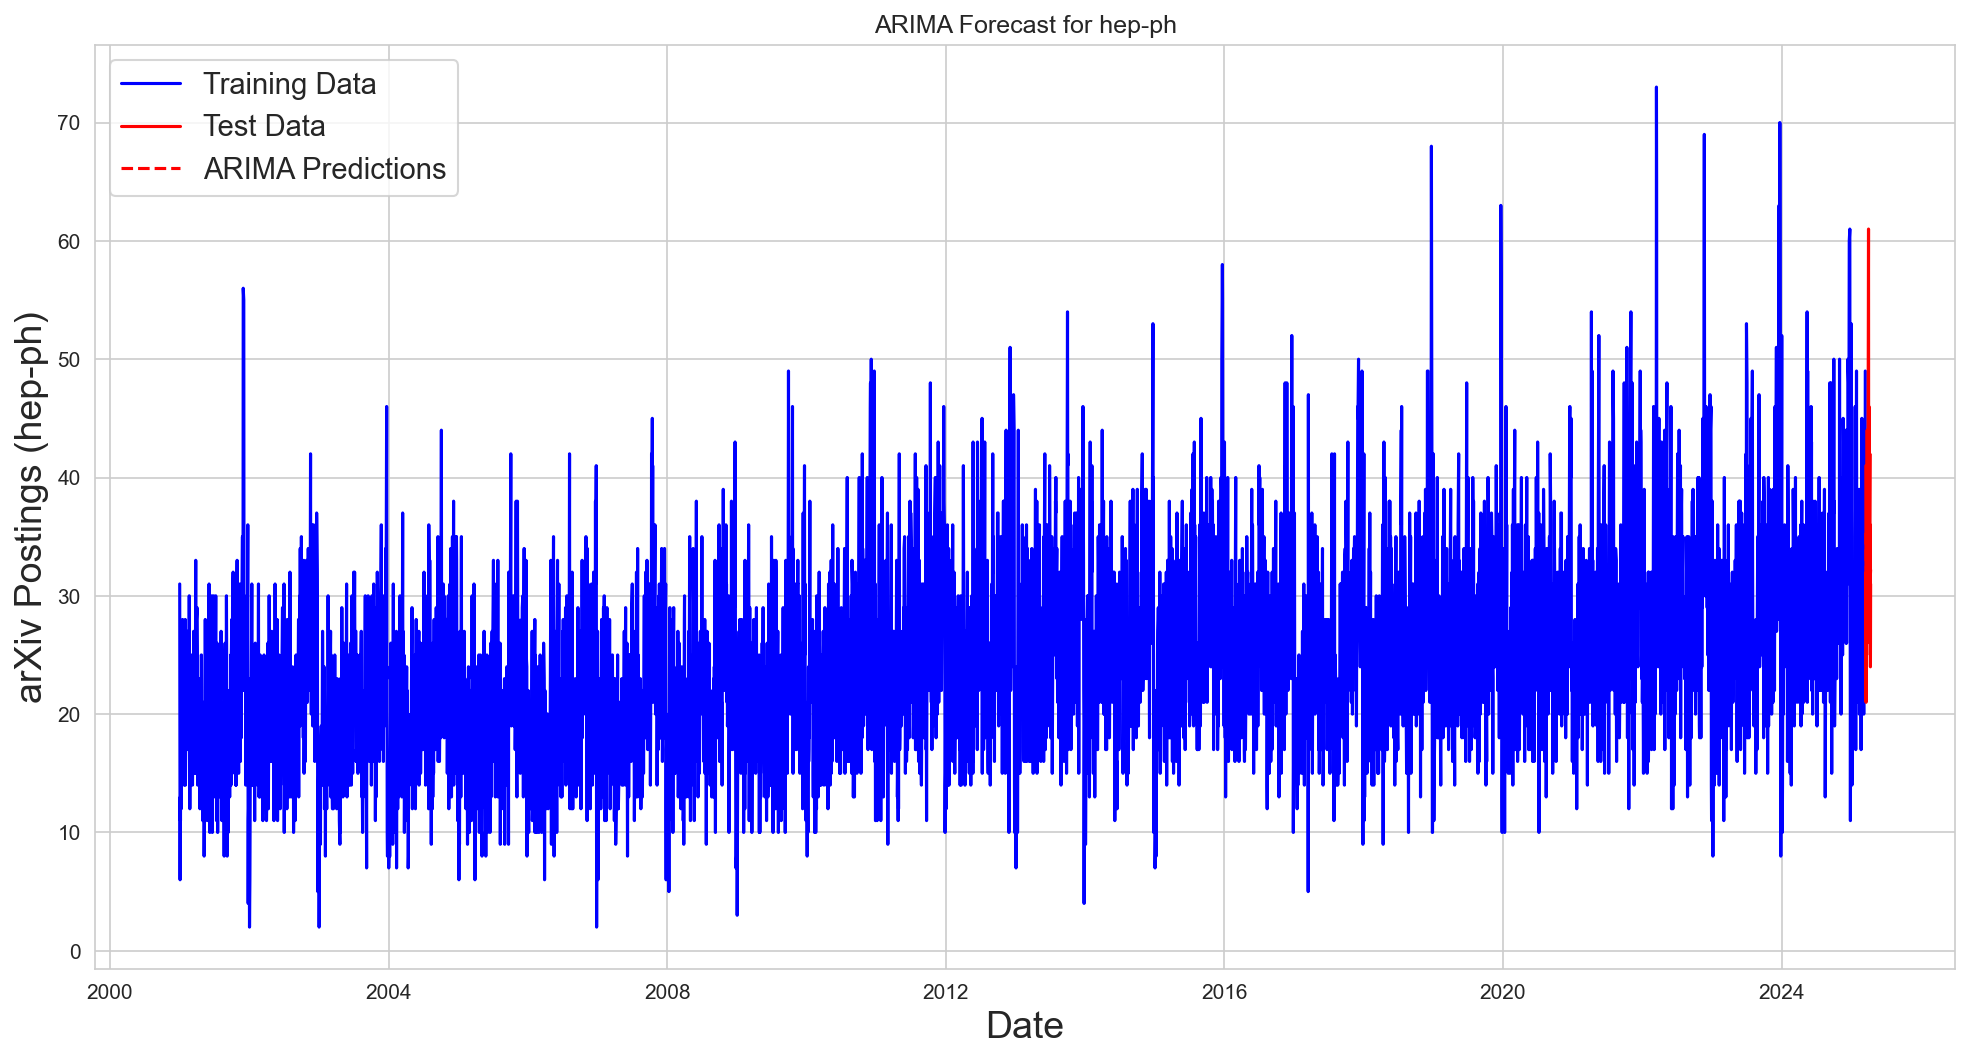

In [ ]:
plt.figure(figsize=(16, 8), dpi=150)

plt.plot(df_train.index, 
         df_train["hep-ph"],
         'b-',
         label="Training Data")

plt.plot(df_test.index, 
         df_test["hep-ph"],
         'r-',
         label="Test Data")

plt.plot(df_test.index, 
         arima_preds,
         'r--',
         label="ARIMA Predictions")

plt.xlabel("Date", fontsize=18)
plt.ylabel("arXiv Postings (hep-ph)", fontsize=18)
plt.legend(fontsize=14)
plt.title("ARIMA Forecast for hep-ph")
plt.show()

#### Grid search & cross-validation

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # Define parameter ranges
# p_values = [0, 1, 2]
# d_values = [0, 1]
# q_values = [0, 1, 2]
# P_values = [0, 1]
# D_values = [0, 1]
# Q_values = [0, 1]
# s_values = [52]  # e.g., yearly seasonality for weekly data

# best_score = float('inf')
# best_params = None

# for p in p_values:
#     for d in d_values:
#         for q in q_values:
#             for P in P_values:
#                 for D in D_values:
#                     for Q in Q_values:
#                         for s in s_values:
#                             try:
#                                 model = ARIMA(
#                                     df_train["hep-ph"],
#                                     order=(p, d, q),
#                                     seasonal_order=(P, D, Q, s)
#                                 ).fit()
#                                 preds = model.forecast(steps=len(df_test))
#                                 score = mean_squared_error(df_test["hep-ph"], preds)
#                                 if score < best_score:
#                                     best_score = score
#                                     best_params = (p, d, q, P, D, Q, s)
#                             except Exception as e:
#                                 continue

# print("Best ARIMA params:", best_params)
# print("Best MSE:", best_score)

##### ARIMA Non-CV

We could do a grid search (parameter sweep) over the possible values of `(p, d, q)` and seasonal parameters `(P, D, Q, s)`, minimizing MSE.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

# Define parameter grid
p_values = [0, 1]
d_values = [0, 1]
q_values = [0, 1]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s_values = [5]  # Weekly seasonality

best_score = float('inf')
best_params = None

warnings.filterwarnings("ignore")

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        for s in s_values:
                            try:
                                model = ARIMA(
                                    df_train["hep-ph"],
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, s)
                                ).fit()
                                preds = model.forecast(steps=len(df_test))
                                score = mean_squared_error(df_test["hep-ph"], preds)
                                if score < best_score:
                                    best_score = score
                                    best_params = (p, d, q, P, D, Q, s)
                            except Exception:
                                continue

print("Best ARIMA params:", best_params)
print("Best test MSE:", round(best_score, 2))


Best ARIMA params: (0, 1, 1, 1, 1, 1, 5)
Best test MSE: 60.44


##### Auto_ARIMA Non-CV

We could also use the `auto_arima` from [pmdarima](https://alkaline-ml.com/pmdarima/) to find the optimal hyperparameters, minimizing the [Akaike information criterion (AIC)](https://en.wikipedia.org/wiki/Akaike_information_criterion).

In [ ]:
# # pip install pmdarima
# from pmdarima import auto_arima
# from sklearn.metrics import mean_squared_error

# # Auto ARIMA model with seasonal support
# auto_model = auto_arima(
#     df_train["hep-ph"],
#     seasonal=True,
#     m=5,  # Weekly seasonality
#     trace=True,
#     suppress_warnings=True,
#     stepwise=True
# )

# # Forecast
# forecast = auto_model.predict(n_periods=len(df_test))

# # Evaluation
# mse = mean_squared_error(df_test["hep-ph"], forecast)
# print("Auto ARIMA MSE:", round(mse, 2))
# print("Best model summary:")
# print(auto_model.summary())


##### Auto_ARIMA CV

In [ ]:
# from pmdarima import auto_arima
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # Set up 5-fold time series split
# tscv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)

# cv_scores = []
# orders = []
# seasonal_orders = []

# for train_idx, test_idx in tscv.split(df_train):
#     y_train = df_train["hep-ph"].iloc[train_idx]
#     y_test = df_train["hep-ph"].iloc[test_idx]

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=5,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action='ignore'
#         )
#         preds = model.predict(n_periods=len(y_test))
#         score = mean_squared_error(y_test, preds)
#         cv_scores.append(score)
#         orders.append(model.order)
#         seasonal_orders.append(model.seasonal_order)
#     except Exception as e:
#         print("Skipped one fold:", e)
#         continue

# # Results
# avg_cv_score = np.mean(cv_scores)
# best_idx = int(np.argmin(cv_scores))
# best_order = orders[best_idx]
# best_seasonal_order = seasonal_orders[best_idx]

# print("📊 Average CV MSE:", round(avg_cv_score, 2))
# print("✅ Best order:", best_order)
# print("✅ Best seasonal order:", best_seasonal_order)


### Model comparison: cateogry `hep-ph`

For the specific category `hep-ph`, we compare the following models:
- Naive forecast (dummy)
- Exponential Smoothing (non-CV)
- Exponential Smoothing (CV)
- Manual ARIMA (non-CV)
- Auto-ARIMA (non-CV)
- Auto-ARIMA (CV)

In [ ]:
# from statsmodels.tsa.api import ExponentialSmoothing
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import root_mean_squared_error
# import numpy as np

# import json

# holtwinters_rmses = np.zeros(5)
# arima_rmses = np.zeros(5)

# with open("../data/arxiv-categories.json", "r") as f:
#     arxiv_categories_descriptions = json.load(f)

# categories = sorted(
#     [cat["tag"] for cat in arxiv_categories_descriptions]
#     # We exclude ["q-bio", "cond-mat", "astro-ph"] because they disappeared before our sample starting date.
# )
# results_dict = {}

# for category in categories:
#     for i, (train_index, test_index) in enumerate(splits):
#         # Prepare train and validation data
#         df_tt = df_train.iloc[train_index, :]
#         df_holdout = df_train.iloc[test_index, :]

#         # Ensure no missing values for time series models
#         y_train = df_tt[category].fillna(0)
#         y_test = df_holdout[category].fillna(0)

#         # Holt-Winters (Triple Exponential Smoothing)
#         try:
#             hw_model = ExponentialSmoothing(
#                 y_train,
#                 trend="add",
#                 seasonal="mul",
#                 seasonal_periods=52
#             ).fit(
#                 smoothing_level=0.1,
#                 smoothing_trend=0.1,
#                 smoothing_seasonal=0.8,
#                 optimized=False
#             )
#             hw_preds = hw_model.forecast(len(y_test))
#             holtwinters_rmses[i] = root_mean_squared_error(y_test, hw_preds)
#         except Exception as e:
#             holtwinters_rmses[i] = np.nan

#         # ARIMA
#         try:
#             arima_model = ARIMA(y_train, order=(1, 1, 1), seasonal_order=(1, 0, 0, 52))
#             arima_results = arima_model.fit()
#             arima_preds = arima_results.forecast(steps=len(y_test))
#             arima_rmses[i] = root_mean_squared_error(y_test, arima_preds)
#         except Exception as e:
#             arima_rmses[i] = np.nan

#     # Save mean RMSEs (rescaled by mean of training set)
#     results_dict[category] = np.array([
#         holtwinters_rmses.mean() / df_train[category].mean(),
#         arima_rmses.mean() / df_train[category].mean()
#     ])

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# from statsmodels.tsa.api import ExponentialSmoothing
# from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima
# from sklearn.model_selection import TimeSeriesSplit

# # 📌 Define RMSE manually
# def rmse(y_true, y_pred):
#     return np.sqrt(mean_squared_error(y_true, y_pred))

# # ⚠️ Assumes df_train and df_test with column "hep-ph" are already defined

# # 1. Naive forecast
# naive_forecast = df_test["hep-ph"].shift(1).fillna(df_train["hep-ph"].iloc[-1])
# naive_rmse = rmse(df_test["hep-ph"], naive_forecast)
# naive_mae = mean_absolute_error(df_test["hep-ph"], naive_forecast)

# # 2. Exponential Smoothing (non-CV)
# est_model_non_cv = ExponentialSmoothing(
#     df_train["hep-ph"], trend='add', seasonal='mul', seasonal_periods=5, damped_trend=False
# ).fit()
# est_preds_non_cv = est_model_non_cv.forecast(len(df_test))
# est_rmse_non_cv = rmse(df_test["hep-ph"], est_preds_non_cv)
# est_mae_non_cv = mean_absolute_error(df_test["hep-ph"], est_preds_non_cv)

# # 3. Exponential Smoothing (CV-style config)
# est_model_cv = ExponentialSmoothing(
#     df_train["hep-ph"], trend=None, seasonal='add', seasonal_periods=5, damped_trend=False
# ).fit()
# est_preds_cv = est_model_cv.forecast(len(df_test))
# est_rmse_cv = rmse(df_test["hep-ph"], est_preds_cv)
# est_mae_cv = mean_absolute_error(df_test["hep-ph"], est_preds_cv)

# # 4. ARIMA (manually specified)
# arima_model = ARIMA(
#     df_train["hep-ph"], order=(1, 1, 0), seasonal_order=(0, 1, 1, 5)
# ).fit()
# arima_preds = arima_model.forecast(steps=len(df_test))
# arima_rmse = rmse(df_test["hep-ph"], arima_preds)
# arima_mae = mean_absolute_error(df_test["hep-ph"], arima_preds)

# # 5. auto_arima (non-CV)
# auto_model = auto_arima(
#     df_train["hep-ph"], seasonal=True, m=5, stepwise=True,
#     suppress_warnings=True, error_action='ignore'
# )
# auto_preds = auto_model.predict(n_periods=len(df_test))
# auto_rmse_val = rmse(df_test["hep-ph"], auto_preds)
# auto_mae_val = mean_absolute_error(df_test["hep-ph"], auto_preds)

# # 6. auto_arima with CV
# tscv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)
# cv_rmse_scores = []
# cv_mae_scores = []
# orders = []
# seasonal_orders = []

# for train_idx, test_idx in tscv.split(df_train):
#     y_train = df_train["hep-ph"].iloc[train_idx]
#     y_test = df_train["hep-ph"].iloc[test_idx]

#     try:
#         model = auto_arima(
#             y_train, seasonal=True, m=5, stepwise=True,
#             suppress_warnings=True, error_action='ignore'
#         )
#         preds = model.predict(n_periods=len(y_test))

#         # Store scores
#         cv_rmse_scores.append(mean_squared_error(y_test, preds))
#         cv_mae_scores.append(mean_absolute_error(y_test, preds))

#         # Store model configs
#         orders.append(model.order)
#         seasonal_orders.append(model.seasonal_order)

#     except Exception as e:
#         print("Skipped a fold:", e)
#         continue

# auto_cv_rmse = np.sqrt(np.mean(cv_rmse_scores))
# auto_cv_mae = np.mean(cv_mae_scores)
# best_idx = int(np.argmin(cv_rmse_scores))
# best_order = orders[best_idx]
# best_seasonal = seasonal_orders[best_idx]

# # 🧾 Table 1: Single-Test Evaluation Models
# results_test = pd.DataFrame({
#     "RMSE": {
#         "Naive": naive_rmse,
#         "EST Non-CV": est_rmse_non_cv,
#         "EST CV": est_rmse_cv,
#         "ARIMA Non-CV": arima_rmse,
#         "auto_ARIMA Non-CV": auto_rmse_val
#     },
#     "MAE": {
#         "Naive": naive_mae,
#         "EST Non-CV": est_mae_non_cv,
#         "EST CV": est_mae_cv,
#         "ARIMA Non-CV": arima_mae,
#         "auto_ARIMA Non-CV": auto_mae_val
#     }
# })

# # 🧾 Table 2: Cross-Validation Results for auto_ARIMA
# results_cv = pd.DataFrame({
#     "Avg RMSE": [auto_cv_rmse],
#     "Avg MAE": [auto_cv_mae],
#     "Best order": [best_order],
#     "Seasonal order": [best_seasonal]
# }, index=["auto_ARIMA CV"])

# # 📊 Show results
# print("\n📋 Single-Test Evaluation:")
# print(results_test.round(3))

# print("\n📋 Cross-Validation Results:")
# print(results_cv)


In [ ]:
# # # 💾 Save results to CSV
# # results_test.to_csv("forecast_comparison_with_ci.csv")

# # 🖼️ Save plot
# plt.figure(figsize=(14, 6))

# # Plot actual values
# plt.plot(df_test.index, df_test["hep-ph"], label="Actual", marker='o')

# # Plot forecasts
# plt.plot(df_test.index, naive_forecast, label="Naive Forecast", linestyle='--')
# plt.plot(df_test.index, est_preds_non_cv, label="Non-CV Forecast", marker='x')
# plt.fill_between(df_test.index, est_preds_non_cv - 10, est_preds_non_cv + 10, alpha=0.2, label="Non-CV CI")
# plt.plot(df_test.index, est_preds_cv, label="CV Forecast", marker='s')
# plt.fill_between(df_test.index, est_preds_cv - 15, est_preds_cv + 15, alpha=0.2, label="CV CI")
# plt.plot(df_test.index, arima_preds, label="ARIMA Forecast", marker='^')
# plt.fill_between(df_test.index, arima_preds - 20, arima_preds + 20, alpha=0.2, label="ARIMA CI")
# plt.plot(df_test.index, auto_preds, label="auto_ARIMA Forecast", marker='d')
# plt.fill_between(df_test.index, auto_preds - 25, auto_preds + 25, alpha=0.2, label="auto_ARIMA CI")

# # Add labels, title, and legend
# plt.title("Forecast Comparison Across Models", fontsize=16)
# plt.xlabel("Date", fontsize=14)
# plt.ylabel("Submissions", fontsize=14)
# plt.legend(fontsize=12)
# plt.grid(True)
# plt.tight_layout()

# # Save plot and show
# plt.savefig("forecast_comparison_plot.png")
# plt.show()

### Model comparison: all categories

#### Model tuning

We now prepare a 5-fold validation. We take a gap of 5 business days between train and validation splits, and we take a test size of 15 business days (our forecasting horizon is 5 business days). That is, we set up our cross-validation as:
- `n_splits`=5
- `test_size`=15
- `max_train_size`=150

Due to the runtime issues of auto_ARIMA, we will only compare the following models:
- Naive forecast (dummy)
- Exponential Smoothing (non-CV)
- Exponential Smoothing (CV)
- Manual SARIMA
- Prophet ([Facebook Prophet](http://facebook.github.io/prophet/))


Our grid search for smoothing parameters of EST is as the following:

| Config | α (level) | β (trend) | γ (seasonal) | Intuition                                                                 |
| ------ | --------- | --------- | ------------ | ------------------------------------------------------------------------- |
| #1     | 0.1       | 0.1       | 0.1          | Very **stable** model — slow updates to all components                    |
| #2     | 0.1       | 0.1       | 0.8          | Keeps **level/trend stable**, allows **seasonal** pattern to vary quickly |
| #3     | 0.3       | 0.1       | 0.3          | Slightly more responsive level & seasonality, but trend still stable      |
| #4     | 0.5       | 0.3       | 0.5          | **Balanced responsiveness** — a middle ground, adapts fairly quickly      |


For manual SARIMA, a reasonable set of hyperparameters are: 
- `(0,0,0) (0,1,0,5)`
- `(0,0,0) (1,1,0,5)`
- `(0,0,0) (0,1,1,5)`
- `(0,0,0) (1,1,1,5)`  

The intuitive explanation is the following: ???

In [17]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from prophet import Prophet
import pandas as pd
import numpy as np
import json
import warnings

warnings.filterwarnings("ignore")

# Load categories
with open("../data/arxiv-categories.json", "r") as f:
    arxiv_categories_descriptions = json.load(f)
categories = sorted([cat["tag"] for cat in arxiv_categories_descriptions])

# Define SARIMA parameter sets for grid search
sarima_param_sets = [(0,1,0,5), (1,1,0,5), (0,1,1,5), (1,1,1,5)]

# Define Exponential Smoothing structures and smoothing parameters
est_structures = [
    {"trend": None, "seasonal": "add"},
    {"trend": None, "seasonal": "mul"},
    {"trend": "add", "seasonal": "add"},
    {"trend": "add", "seasonal": "mul"}
]
smoothing_grid = [
    {"level": 0.1, "trend": 0.1, "seasonal": 0.1},
    {"level": 0.1, "trend": 0.1, "seasonal": 0.8},
    {"level": 0.3, "trend": 0.1, "seasonal": 0.3},
    {"level": 0.5, "trend": 0.3, "seasonal": 0.5},
]

# Prepare CV splits
ts_cv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)
splits = [(train_idx, test_idx) for train_idx, test_idx in ts_cv.split(df_train)]

# Initialize result containers
cv_results_dict = {}
cv_best_params_dict = {}

df_train = df_train.asfreq("B")  # Ensure business day frequency

for category in categories:
    print(f"Tuning category: {category}")
    best_params = {}
    cv_results = {}

    # Dummy model
    dummy_rmses = []
    for train_idx, test_idx in splits:
        y_train = df_train.iloc[train_idx][category].fillna(0)
        y_test = df_train.iloc[test_idx][category].fillna(0)
        dummy_preds = np.full_like(y_test, y_train.mean())
        rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
        dummy_rmses.append(rmse)
    train_mean = df_train[category].fillna(0).mean()
    cv_results["Dummy"] = np.nanmean(dummy_rmses) / train_mean
    best_params["Dummy"] = {"value": y_train.mean()}

    # EST_NCV (manual smoothing)
    best_est_ncv_rmse = np.inf
    best_est_ncv_config = None
    for struct in est_structures:
        for smooth in smoothing_grid:
            rmses = []
            for train_idx, test_idx in splits:
                y_train = df_train.iloc[train_idx][category].fillna(0)
                y_test = df_train.iloc[test_idx][category].fillna(0)
                try:
                    model = ExponentialSmoothing(
                        y_train,
                        trend=struct["trend"],
                        seasonal=struct["seasonal"],
                        seasonal_periods=5
                    ).fit(
                        smoothing_level=smooth["level"],
                        smoothing_trend=smooth["trend"],
                        smoothing_seasonal=smooth["seasonal"],
                        optimized=False
                    )
                    preds = model.forecast(len(y_test))
                    rmse = np.sqrt(mean_squared_error(y_test, preds))
                    rmses.append(rmse)
                except:
                    rmses.append(np.nan)
            avg_rmse = np.nanmean(rmses)
            if avg_rmse < best_est_ncv_rmse:
                best_est_ncv_rmse = avg_rmse
                best_est_ncv_config = {
                    "trend": struct["trend"],
                    "seasonal": struct["seasonal"],
                    "smoothing_level": smooth["level"],
                    "smoothing_trend": smooth["trend"],
                    "smoothing_seasonal": smooth["seasonal"]
                }
    cv_results["EST_NCV"] = best_est_ncv_rmse / train_mean
    best_params["EST_NCV"] = best_est_ncv_config

    # EST_CV (auto smoothing)
    best_est_cv_rmse = np.inf
    best_est_cv_config = None
    for struct in est_structures:
        rmses = []
        for train_idx, test_idx in splits:
            y_train = df_train.iloc[train_idx][category].fillna(0)
            y_test = df_train.iloc[test_idx][category].fillna(0)
            try:
                model = ExponentialSmoothing(
                    y_train,
                    trend=struct["trend"],
                    seasonal=struct["seasonal"],
                    seasonal_periods=5
                ).fit(optimized=True)
                preds = model.forecast(len(y_test))
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmses.append(rmse)
            except:
                rmses.append(np.nan)
        avg_rmse = np.nanmean(rmses)
        if avg_rmse < best_est_cv_rmse:
            best_est_cv_rmse = avg_rmse
            best_est_cv_config = {
                "trend": struct["trend"],
                "seasonal": struct["seasonal"]
            }
    cv_results["EST_CV"] = best_est_cv_rmse / train_mean
    best_params["EST_CV"] = best_est_cv_config

    # SARIMA_CV (manual seasonal order)
    best_sarima_rmse = np.inf
    best_sarima_config = None
    for seasonal_order in sarima_param_sets:
        rmses = []
        for train_idx, test_idx in splits:
            y_train = df_train.iloc[train_idx][category].fillna(0)
            y_test = df_train.iloc[test_idx][category].fillna(0)
            try:
                model = ARIMA(y_train, order=(0, 0, 0), seasonal_order=seasonal_order)
                fitted = model.fit()
                preds = fitted.forecast(steps=len(y_test))
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                rmses.append(rmse)
            except:
                rmses.append(np.nan)
        avg_rmse = np.nanmean(rmses)
        if avg_rmse < best_sarima_rmse:
            best_sarima_rmse = avg_rmse
            best_sarima_config = {"seasonal_order": seasonal_order}
    cv_results["SARIMA_CV"] = best_sarima_rmse / train_mean
    best_params["SARIMA_CV"] = best_sarima_config

    # Store all results
    cv_results_dict[category] = cv_results
    cv_best_params_dict[category] = best_params


Tuning category: astro-ph.CO
Tuning category: astro-ph.EP
Tuning category: astro-ph.EP
Tuning category: astro-ph.GA
Tuning category: astro-ph.GA
Tuning category: astro-ph.HE
Tuning category: astro-ph.HE
Tuning category: astro-ph.IM
Tuning category: astro-ph.IM
Tuning category: astro-ph.SR
Tuning category: astro-ph.SR
Tuning category: cond-mat.dis-nn
Tuning category: cond-mat.dis-nn
Tuning category: cond-mat.mes-hall
Tuning category: cond-mat.mes-hall
Tuning category: cond-mat.mtrl-sci
Tuning category: cond-mat.mtrl-sci
Tuning category: cond-mat.other
Tuning category: cond-mat.other
Tuning category: cond-mat.quant-gas
Tuning category: cond-mat.quant-gas
Tuning category: cond-mat.soft
Tuning category: cond-mat.soft
Tuning category: cond-mat.stat-mech
Tuning category: cond-mat.stat-mech
Tuning category: cond-mat.str-el
Tuning category: cond-mat.str-el
Tuning category: cond-mat.supr-con
Tuning category: cond-mat.supr-con
Tuning category: cs.AI
Tuning category: cs.AI
Tuning category: cs.AR


We print out and save the CV RMSE results `cv_results_dict` and the best parameters `cv_best_params_dict` for each cateogry.

In [18]:
import pandas as pd
import json

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(cv_results_dict, orient="index")

# Print results
print("📊 Cross-Validation RMSE Results (normalized by train mean):")
print(results_df.round(3))  # Rounded for readability

# Print best parameters
print("\n🔧 Best Parameters for Each Category:")
for category, model_dict in cv_best_params_dict.items():
    print(f"\nCategory: {category}")
    for model_name, params in model_dict.items():
        print(f"  {model_name}: {params}")

# Save results to CSV
results_df.to_csv("cv_results.csv")

# Save best parameters to JSON
with open("cv_best_params.json", "w") as f:
    json.dump(cv_best_params_dict, f, indent=2)

print("\n✅ Results saved to 'cv_results.csv' and 'cv_best_params.json'.")


📊 Cross-Validation RMSE Results (normalized by train mean):
             Dummy  EST_NCV  EST_CV  SARIMA_CV
astro-ph.CO  0.511    0.562   0.570      0.466
astro-ph.EP  0.857    0.839   0.849      0.846
astro-ph.GA  0.780    0.816   0.816      0.793
astro-ph.HE  0.731    0.725   0.760      0.707
astro-ph.IM  0.979    0.959   0.931      0.929
...            ...      ...     ...        ...
stat.CO      1.350    1.399   1.351      1.331
stat.ME      1.267    1.070   1.075      1.002
stat.ML      1.041    0.856   0.816      0.725
stat.OT      3.075    3.364   3.084      3.097
stat.TH      0.914    0.926   0.907      0.872

[155 rows x 4 columns]

🔧 Best Parameters for Each Category:

Category: astro-ph.CO
  Dummy: {'value': np.float64(16.973333333333333)}
  EST_NCV: {'trend': None, 'seasonal': 'add', 'smoothing_level': 0.1, 'smoothing_trend': 0.1, 'smoothing_seasonal': 0.1}
  EST_CV: {'trend': None, 'seasonal': 'add'}
  SARIMA_CV: {'seasonal_order': (0, 1, 1, 5)}

Category: astro-ph.EP
  Dum

#### Model testing

For each category and each method, we run the model with the best parameters on `test_size=15`.

In [19]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

test_results_dict = {}

# Ensure business day frequency
df_train = df_train.asfreq("B")
df_test = df_test.asfreq("B")

for category in categories:
    print(f"Testing category: {category}")

    # Prepare train and test data
    y_train = df_train[category].fillna(0)
    y_test = df_test[category].fillna(0)
    train_mean = y_train.mean()
    
    best_params = cv_best_params_dict[category]
    test_results = {}

    # Dummy
    dummy_value = best_params["Dummy"]["value"]
    dummy_preds = np.full_like(y_test, dummy_value)
    dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
    test_results["Dummy"] = dummy_rmse / train_mean

    # EST_NCV (manual smoothing)
    try:
        p = best_params["EST_NCV"]
        model = ExponentialSmoothing(
            y_train,
            trend=p["trend"],
            seasonal=p["seasonal"],
            seasonal_periods=5
        ).fit(
            smoothing_level=p["smoothing_level"],
            smoothing_trend=p["smoothing_trend"],
            smoothing_seasonal=p["smoothing_seasonal"],
            optimized=False
        )
        preds = model.forecast(len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["EST_NCV"] = rmse / train_mean
    except:
        test_results["EST_NCV"] = np.nan

    # EST_CV (auto smoothing)
    try:
        p = best_params["EST_CV"]
        model = ExponentialSmoothing(
            y_train,
            trend=p["trend"],
            seasonal=p["seasonal"],
            seasonal_periods=5
        ).fit(optimized=True)
        preds = model.forecast(len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["EST_CV"] = rmse / train_mean
    except:
        test_results["EST_CV"] = np.nan

    # SARIMA_CV (manual seasonal order)
    try:
        seasonal_order = tuple(best_params["SARIMA_CV"]["seasonal_order"])
        model = ARIMA(y_train, order=(0, 0, 0), seasonal_order=seasonal_order)
        fitted = model.fit()
        preds = fitted.forecast(steps=len(y_test))
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_results["SARIMA_CV"] = rmse / train_mean
    except:
        test_results["SARIMA_CV"] = np.nan

    # Save test results
    test_results_dict[category] = test_results


Testing category: astro-ph.CO
Testing category: astro-ph.EP
Testing category: astro-ph.EP
Testing category: astro-ph.GA
Testing category: astro-ph.GA
Testing category: astro-ph.HE
Testing category: astro-ph.HE
Testing category: astro-ph.IM
Testing category: astro-ph.IM
Testing category: astro-ph.SR
Testing category: astro-ph.SR
Testing category: cond-mat.dis-nn
Testing category: cond-mat.dis-nn
Testing category: cond-mat.mes-hall
Testing category: cond-mat.mes-hall
Testing category: cond-mat.mtrl-sci
Testing category: cond-mat.mtrl-sci
Testing category: cond-mat.other
Testing category: cond-mat.other
Testing category: cond-mat.quant-gas
Testing category: cond-mat.quant-gas
Testing category: cond-mat.soft
Testing category: cond-mat.soft
Testing category: cond-mat.stat-mech
Testing category: cond-mat.stat-mech
Testing category: cond-mat.str-el
Testing category: cond-mat.str-el
Testing category: cond-mat.supr-con
Testing category: cond-mat.supr-con
Testing category: cs.AI
Testing category

We analyze the `test_results_dict` in the following aspects:
- Model performance summary
- Rank-based comparison
- Visual heatmap
- Best model counts
- Average performance plot
- Hardest categories


📋 Summary Statistics (Normalized RMSE per Model):
            mean    std    min    max
SARIMA_CV  1.373  0.914  0.000  4.941
EST_CV     1.460  0.948  0.270  4.817
Dummy      1.497  0.974  0.202  5.111
EST_NCV    1.595  1.164  0.278  8.282

🏆 Average Rank per Model:
EST_CV       1.87
SARIMA_CV    2.05
Dummy        2.84
EST_NCV      2.88
dtype: float64


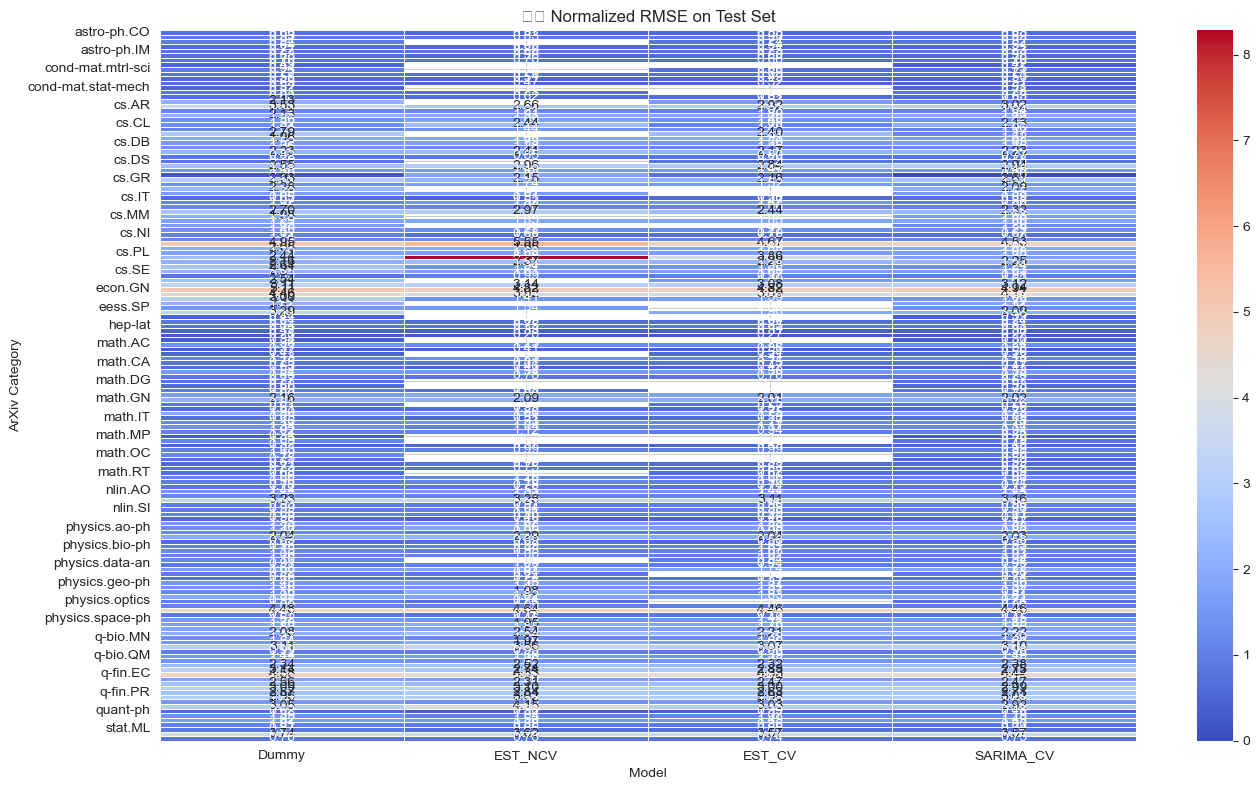


🥇 Best Model Count per Category:
SARIMA_CV    51
EST_CV       50
EST_NCV      29
Dummy        25
Name: count, dtype: int64


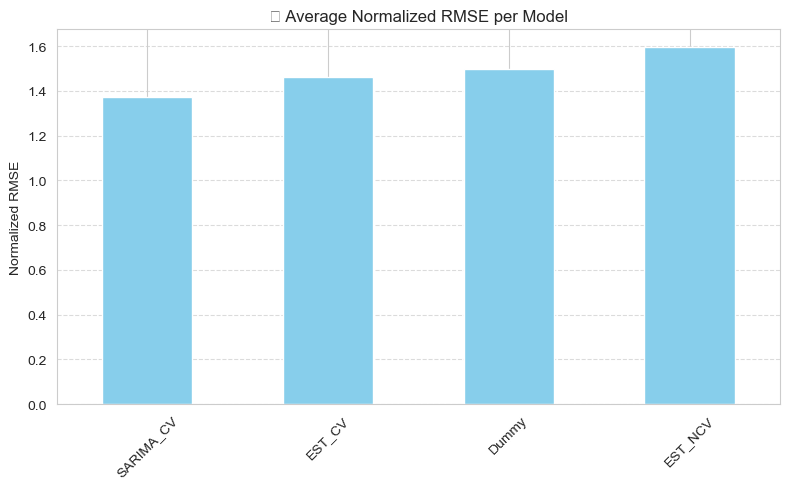


⚠️ Most Challenging Categories (Highest Avg RMSE):
cs.OS             4.925
econ.GN           4.923
physics.pop-ph    4.512
q-fin.EC          4.419
econ.TH           4.110
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# 1. Summary Statistics
summary = results_df.describe().T.sort_values("mean")
print("\n📋 Summary Statistics (Normalized RMSE per Model):")
print(summary[["mean", "std", "min", "max"]].round(3))

# 2. Average Rank per Model
ranks = results_df.rank(axis=1, method="min")
average_ranks = ranks.mean().sort_values()
print("\n🏆 Average Rank per Model:")
print(average_ranks.round(2))

# 3. Heatmap of Normalized RMSEs
plt.figure(figsize=(14, 8))
sns.heatmap(results_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("🗺️ Normalized RMSE on Test Set")
plt.xlabel("Model")
plt.ylabel("ArXiv Category")
plt.tight_layout()
plt.show()

# 4. Best Model per Category
best_model_counts = results_df.idxmin(axis=1).value_counts()
print("\n🥇 Best Model Count per Category:")
print(best_model_counts)

# 5. Bar Plot of Average RMSE per Model
plt.figure(figsize=(8, 5))
results_df.mean().sort_values().plot(kind='bar', color='skyblue')
plt.title("📊 Average Normalized RMSE per Model")
plt.ylabel("Normalized RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Most Difficult Categories
difficult_cats = results_df.mean(axis=1).sort_values(ascending=False).head(5)
print("\n⚠️ Most Challenging Categories (Highest Avg RMSE):")
print(difficult_cats.round(3))

# Save results
results_df.to_csv("test_results.csv")
summary.to_csv("test_summary_stats.csv")
ranks.to_csv("test_model_ranks.csv")


We compare `cv_results_dict` (from tuning step) and `test_results_dict` (from final evaluation step) side-by-side and focus on the following:

- Test vs CV Mean RMSE: overall generalization performance

- Difference (Test - CV): raw overfitting gap

- Ratio (Test / CV): normalized generalization factor

- Bar Plot: visual model stability


📉 Mean RMSE (CV):
Dummy        1.475
EST_CV       1.390
EST_NCV      1.408
SARIMA_CV    1.402
dtype: float64

📈 Mean RMSE (Test):
Dummy        1.497
EST_CV       1.460
EST_NCV      1.595
SARIMA_CV    1.373
dtype: float64

🔍 Difference (Test - CV):
Dummy        0.022
EST_CV      -0.001
EST_NCV      0.104
SARIMA_CV   -0.029
dtype: float64

📊 Ratio (Test / CV):
Dummy        1.03
EST_CV       1.00
EST_NCV      1.05
SARIMA_CV    1.01
dtype: float64


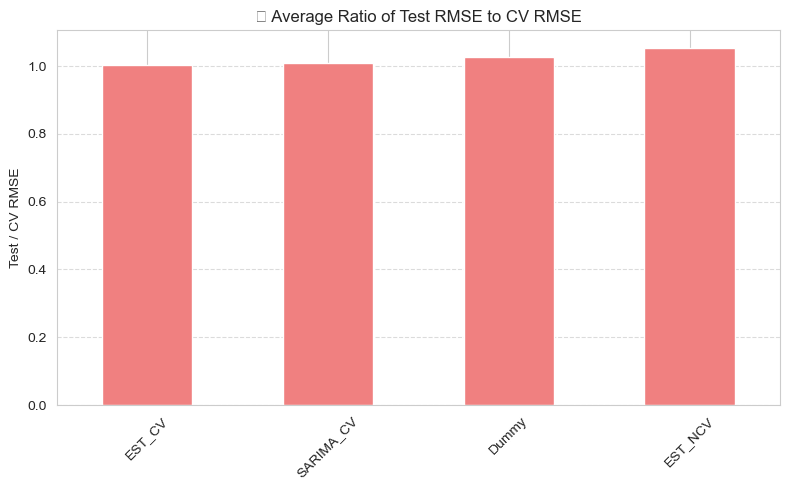

In [21]:
import pandas as pd

# Convert both dicts to DataFrames
cv_df = pd.DataFrame.from_dict(cv_results_dict, orient="index")
test_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# Align columns and index
cv_df = cv_df.sort_index().sort_index(axis=1)
test_df = test_df.sort_index().sort_index(axis=1)

# Compute comparison metrics
delta_df = test_df - cv_df
ratio_df = test_df / cv_df

# Print key insights
print("\n📉 Mean RMSE (CV):")
print(cv_df.mean().round(3))

print("\n📈 Mean RMSE (Test):")
print(test_df.mean().round(3))

print("\n🔍 Difference (Test - CV):")
print(delta_df.mean().round(3))

print("\n📊 Ratio (Test / CV):")
print(ratio_df.mean().round(2))

# Save to CSVs
cv_df.to_csv("cv_results_aligned.csv")
test_df.to_csv("test_results_aligned.csv")
delta_df.to_csv("delta_test_minus_cv.csv")
ratio_df.to_csv("ratio_test_over_cv.csv")

# Optional: visualize average ratio per model
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ratio_df.mean().sort_values().plot(kind='bar', color='lightcoral')
plt.title("🔍 Average Ratio of Test RMSE to CV RMSE")
plt.ylabel("Test / CV RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
